In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from pathlib import Path
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [3]:
project_dir = Path.cwd()
audio_dir = project_dir / "ESC-50" / "audio"
metadata_path = project_dir / "ESC-50" / "meta" / "esc50.csv"

print("Project:", project_dir)
print("Audio:", audio_dir)
print("Metadata:", metadata_path)
print("Audio exists:", audio_dir.exists())
print("Metadata exists:", metadata_path.exists())

Project: c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI
Audio: c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\ESC-50\audio
Metadata: c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\ESC-50\meta\esc50.csv
Audio exists: True
Metadata exists: True


In [4]:
metadata = pd.read_csv(metadata_path)

target_classes = ["cat", "dog", "cow", "sheep", "frog"]

animal_df = metadata[
    metadata["category"].isin(target_classes)
].copy()

print("Toplam örnek:", len(animal_df))
print()
print(animal_df["category"].value_counts())

Toplam örnek: 200

category
dog      40
sheep    40
frog     40
cow      40
cat      40
Name: count, dtype: int64


In [5]:
def add_noise_snr(y, snr_db, random_state=None):

    rng = np.random.default_rng(random_state)

    signal_power = np.mean(y ** 2)

    noise = rng.normal(0, 1, len(y))
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (10 ** (snr_db / 10))

    noise = noise * np.sqrt(
        target_noise_power / (noise_power + 1e-12)
    )

    noisy_y = y + noise

    return noisy_y

In [6]:
sample_row = animal_df.iloc[0]

sample_path = audio_dir / sample_row["filename"]

y, sr = librosa.load(
    sample_path,
    sr=22050,
    duration=5.0
)

y_noisy = add_noise_snr(
    y,
    snr_db=10,
    random_state=42
)

print("Class:", sample_row["category"])
print("Sample rate:", sr)
print("Original shape:", y.shape)
print("Noisy shape:", y_noisy.shape)

Class: dog
Sample rate: 22050
Original shape: (110250,)
Noisy shape: (110250,)


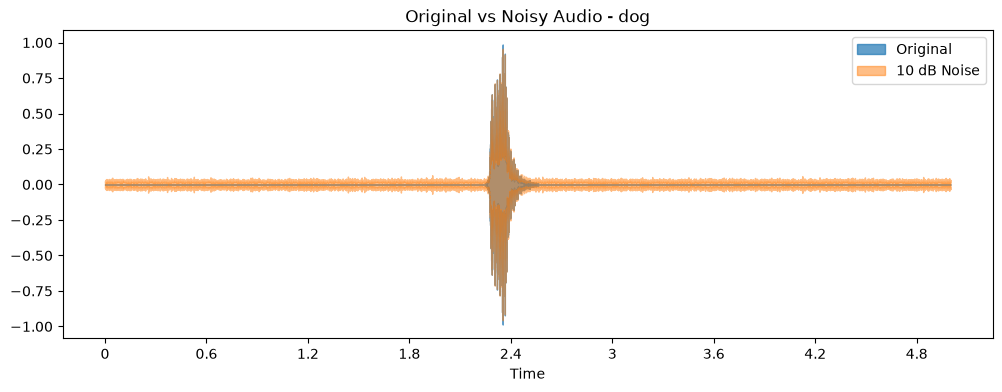

In [7]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    y,
    sr=sr,
    alpha=0.7,
    label="Original"
)

librosa.display.waveshow(
    y_noisy,
    sr=sr,
    alpha=0.5,
    label="10 dB Noise"
)

plt.title(
    f"Original vs Noisy Audio - {sample_row['category']}"
)
plt.legend()
plt.show()

In [8]:
def extract_features_from_audio(y, sr):

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # Delta MFCC
    delta = librosa.feature.delta(mfcc)

    delta_mean = np.mean(delta, axis=1)
    delta_std = np.std(delta, axis=1)

    # Chroma
    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr
    )

    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)

    # Spectral features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)

    spectral_features = [
        np.mean(centroid), np.std(centroid),
        np.mean(bandwidth), np.std(bandwidth),
        np.mean(rolloff), np.std(rolloff),
        np.mean(zcr), np.std(zcr)
    ]

    features = np.concatenate([
        mfcc_mean,
        mfcc_std,
        delta_mean,
        delta_std,
        chroma_mean,
        chroma_std,
        spectral_features
    ])

    return features

In [9]:
test_features = extract_features_from_audio(y, sr)

print("Feature count:", len(test_features))
print("Shape:", test_features.shape)

Feature count: 84
Shape: (84,)


In [10]:
test_noisy_features = extract_features_from_audio(
    y_noisy,
    sr
)

print("Clean:", test_features.shape)
print("Noisy:", test_noisy_features.shape)

print(
    "Features identical:",
    np.allclose(test_features, test_noisy_features)
)

Clean: (84,)
Noisy: (84,)
Features identical: False


In [11]:
snr_levels = [20, 10, 0]

clean_features = []
noisy_features = {
    20: [],
    10: [],
    0: []
}

labels = []
fold_values = []

for i, (_, row) in enumerate(animal_df.iterrows()):

    audio_path = audio_dir / row["filename"]

    y_audio, sr_audio = librosa.load(
        audio_path,
        sr=22050,
        duration=5.0
    )

    # Clean features
    clean_feat = extract_features_from_audio(
        y_audio,
        sr_audio
    )

    clean_features.append(clean_feat)

    # Aynı sesin farklı noise seviyeleri
    for snr in snr_levels:

        noisy_audio = add_noise_snr(
            y_audio,
            snr_db=snr,
            random_state=42 + i
        )

        noisy_feat = extract_features_from_audio(
            noisy_audio,
            sr_audio
        )

        noisy_features[snr].append(noisy_feat)

    labels.append(row["category"])
    fold_values.append(row["fold"])

clean_features = np.array(clean_features)

for snr in snr_levels:
    noisy_features[snr] = np.array(
        noisy_features[snr]
    )

labels = np.array(labels)
fold_values = np.array(fold_values)

print("Clean:", clean_features.shape)

for snr in snr_levels:
    print(
        f"{snr} dB:",
        noisy_features[snr].shape
    )

Clean: (200, 84)
20 dB: (200, 84)
10 dB: (200, 84)
0 dB: (200, 84)


In [12]:
conditions = {
    "Clean": clean_features,
    "20 dB": noisy_features[20],
    "10 dB": noisy_features[10],
    "0 dB": noisy_features[0]
}

results = {
    condition: []
    for condition in conditions
}

for test_fold in range(1, 6):

    train_mask = fold_values != test_fold
    test_mask = fold_values == test_fold

    X_train = clean_features[train_mask]
    y_train = labels[train_mask]

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    print(f"\nFold {test_fold}")

    for condition_name, X_condition in conditions.items():

        X_test = X_condition[test_mask]
        y_test = labels[test_mask]

        predictions = model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        results[condition_name].append(
            accuracy
        )

        print(
            f"{condition_name:6s}: "
            f"{accuracy:.3f}"
        )


Fold 1
Clean : 0.750
20 dB : 0.450
10 dB : 0.200
0 dB  : 0.200

Fold 2
Clean : 0.750
20 dB : 0.600
10 dB : 0.325
0 dB  : 0.200

Fold 3
Clean : 0.800
20 dB : 0.575
10 dB : 0.300
0 dB  : 0.200

Fold 4
Clean : 0.775
20 dB : 0.675
10 dB : 0.375
0 dB  : 0.275

Fold 5
Clean : 0.625
20 dB : 0.550
10 dB : 0.300
0 dB  : 0.200


In [13]:
for condition, scores in results.items():
    print(
        condition,
        "Mean:",
        round(np.mean(scores), 3),
        "Std:",
        round(np.std(scores), 3)
    )

Clean Mean: 0.74 Std: 0.06
20 dB Mean: 0.57 Std: 0.073
10 dB Mean: 0.3 Std: 0.057
0 dB Mean: 0.215 Std: 0.03


In [14]:
aug_results = {
    "Clean": [],
    "20 dB": [],
    "10 dB": [],
    "0 dB": []
}

for test_fold in range(1, 6):

    train_mask = fold_values != test_fold
    test_mask = fold_values == test_fold

    # -------------------------
    # TRAINING DATA
    # -------------------------

    X_train_clean = clean_features[train_mask]
    y_train_clean = labels[train_mask]

    # Training setinin 20 ve 10 dB versiyonları
    X_train_20 = noisy_features[20][train_mask]
    X_train_10 = noisy_features[10][train_mask]

    # Clean + noisy training data
    X_train_aug = np.vstack([
        X_train_clean,
        X_train_20,
        X_train_10
    ])

    y_train_aug = np.concatenate([
        y_train_clean,
        y_train_clean,
        y_train_clean
    ])

    # -------------------------
    # MODEL
    # -------------------------

    model_aug = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model_aug.fit(
        X_train_aug,
        y_train_aug
    )

    # -------------------------
    # TEST
    # -------------------------

    test_conditions = {
        "Clean": clean_features[test_mask],
        "20 dB": noisy_features[20][test_mask],
        "10 dB": noisy_features[10][test_mask],
        "0 dB": noisy_features[0][test_mask]
    }

    y_test = labels[test_mask]

    print(f"\nFold {test_fold}")

    for condition, X_test in test_conditions.items():

        predictions = model_aug.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        aug_results[condition].append(
            accuracy
        )

        print(
            f"{condition:6s}: "
            f"{accuracy:.3f}"
        )


Fold 1
Clean : 0.700
20 dB : 0.775
10 dB : 0.775
0 dB  : 0.475

Fold 2
Clean : 0.700
20 dB : 0.875
10 dB : 0.850
0 dB  : 0.550

Fold 3
Clean : 0.700
20 dB : 0.875
10 dB : 0.800
0 dB  : 0.525

Fold 4
Clean : 0.650
20 dB : 0.800
10 dB : 0.825
0 dB  : 0.575

Fold 5
Clean : 0.500
20 dB : 0.625
10 dB : 0.675
0 dB  : 0.450


In [15]:
print("\n--- Augmented RF Results ---")

for condition, scores in aug_results.items():

    print(
        condition,
        "Mean:",
        round(np.mean(scores), 3),
        "Std:",
        round(np.std(scores), 3)
    )


--- Augmented RF Results ---
Clean Mean: 0.65 Std: 0.077
20 dB Mean: 0.79 Std: 0.092
10 dB Mean: 0.785 Std: 0.06
0 dB Mean: 0.515 Std: 0.046


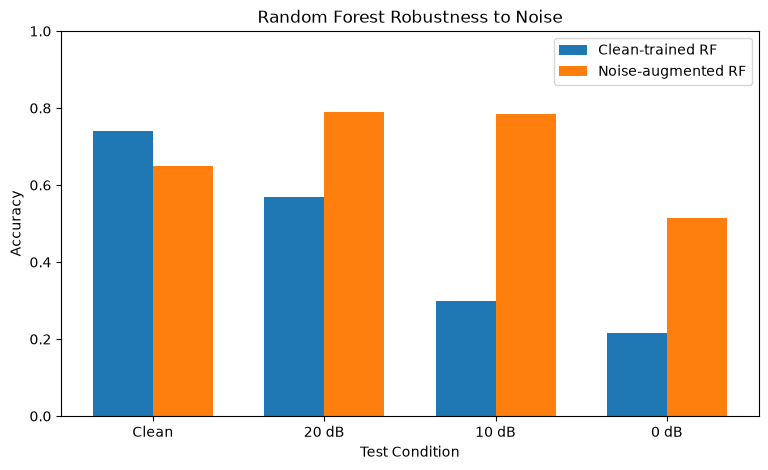

In [16]:
conditions_order = ["Clean", "20 dB", "10 dB", "0 dB"]

baseline_means = [
    np.mean(results[c])
    for c in conditions_order
]

augmented_means = [
    np.mean(aug_results[c])
    for c in conditions_order
]

x = np.arange(len(conditions_order))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    baseline_means,
    width,
    label="Clean-trained RF"
)

plt.bar(
    x + width/2,
    augmented_means,
    width,
    label="Noise-augmented RF"
)

plt.xticks(x, conditions_order)
plt.ylim(0, 1)

plt.xlabel("Test Condition")
plt.ylabel("Accuracy")
plt.title("Random Forest Robustness to Noise")

plt.legend()
plt.show()

In [17]:
confidence_records = []

for test_fold in range(1, 6):

    train_mask = fold_values != test_fold
    test_mask = fold_values == test_fold

    # Augmented training set
    X_train_clean = clean_features[train_mask]
    X_train_20 = noisy_features[20][train_mask]
    X_train_10 = noisy_features[10][train_mask]

    y_train = labels[train_mask]

    X_train_aug = np.vstack([
        X_train_clean,
        X_train_20,
        X_train_10
    ])

    y_train_aug = np.concatenate([
        y_train,
        y_train,
        y_train
    ])

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )

    model.fit(X_train_aug, y_train_aug)

    # Dört test koşulu
    test_conditions = {
        "Clean": clean_features[test_mask],
        "20 dB": noisy_features[20][test_mask],
        "10 dB": noisy_features[10][test_mask],
        "0 dB": noisy_features[0][test_mask]
    }

    y_test = labels[test_mask]

    for condition, X_test in test_conditions.items():

        probabilities = model.predict_proba(X_test)

        predictions = model.classes_[
            np.argmax(probabilities, axis=1)
        ]

        confidences = np.max(
            probabilities,
            axis=1
        )

        for true_label, pred_label, confidence in zip(
            y_test,
            predictions,
            confidences
        ):

            confidence_records.append({
                "fold": test_fold,
                "condition": condition,
                "true_label": true_label,
                "prediction": pred_label,
                "confidence": confidence,
                "correct": true_label == pred_label
            })

confidence_df = pd.DataFrame(confidence_records)

print(confidence_df.shape)
confidence_df.head()

(800, 6)


,fold,condition,true_label,prediction,confidence,correct
0,1,Clean,dog,dog,0.280000,True
1,1,Clean,dog,cat,0.413333,False
2,1,Clean,sheep,frog,0.336667,False
3,1,Clean,frog,frog,0.453333,True
4,1,Clean,frog,frog,0.680000,True


In [18]:
confidence_summary = confidence_df.groupby(
    ["condition", "correct"]
)["confidence"].agg(
    ["mean", "median", "count"]
)

print(confidence_summary)

                       mean    median  count
condition correct                           
0 dB      False    0.405017  0.393333     97
          True     0.476505  0.466667    103
10 dB     False    0.409147  0.376667     43
          True     0.606645  0.613333    157
20 dB     False    0.409286  0.405000     42
          True     0.568207  0.556667    158
Clean     False    0.386333  0.363333     70
          True     0.496051  0.486667    130


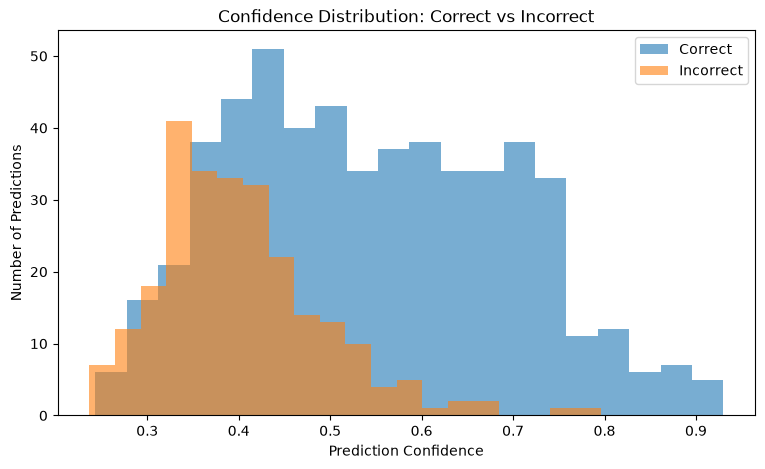

In [19]:
correct_conf = confidence_df[
    confidence_df["correct"] == True
]["confidence"]

wrong_conf = confidence_df[
    confidence_df["correct"] == False
]["confidence"]

plt.figure(figsize=(9, 5))

plt.hist(
    correct_conf,
    bins=20,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    wrong_conf,
    bins=20,
    alpha=0.6,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Predictions")
plt.title("Confidence Distribution: Correct vs Incorrect")

plt.legend()
plt.show()

In [20]:
thresholds = np.arange(0.30, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    accepted = confidence_df[
        confidence_df["confidence"] >= threshold
    ]

    coverage = len(accepted) / len(confidence_df)

    if len(accepted) > 0:
        accepted_accuracy = accepted["correct"].mean()
    else:
        accepted_accuracy = np.nan

    threshold_results.append({
        "threshold": threshold,
        "coverage": coverage,
        "accepted_accuracy": accepted_accuracy,
        "accepted_count": len(accepted)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(3))

    threshold  coverage  accepted_accuracy  accepted_count
0        0.30     0.940              0.702             752
1        0.35     0.845              0.743             676
2        0.40     0.702              0.795             562
3        0.45     0.540              0.861             432
4        0.50     0.441              0.901             353
5        0.55     0.344              0.945             275
6        0.60     0.271              0.963             217
7        0.65     0.196              0.975             157
8        0.70     0.120              0.979              96
9        0.75     0.069              0.964              55
10       0.80     0.036              1.000              29
11       0.85     0.016              1.000              13
12       0.90     0.004              1.000               3


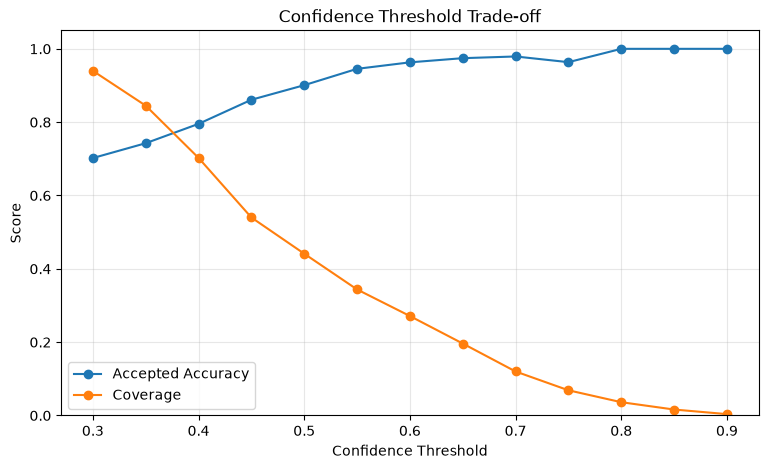

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["accepted_accuracy"],
    marker="o",
    label="Accepted Accuracy"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["coverage"],
    marker="o",
    label="Coverage"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.title("Confidence Threshold Trade-off")

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [22]:
selected_threshold = 0.50

condition_results = []

for condition in ["Clean", "20 dB", "10 dB", "0 dB"]:

    subset = confidence_df[
        confidence_df["condition"] == condition
    ]

    accepted = subset[
        subset["confidence"] >= selected_threshold
    ]

    coverage = len(accepted) / len(subset)

    if len(accepted) > 0:
        accepted_accuracy = accepted["correct"].mean()
    else:
        accepted_accuracy = np.nan

    condition_results.append({
        "condition": condition,
        "total": len(subset),
        "accepted": len(accepted),
        "rejected": len(subset) - len(accepted),
        "coverage": coverage,
        "accepted_accuracy": accepted_accuracy
    })

condition_threshold_df = pd.DataFrame(
    condition_results
)

print(condition_threshold_df.round(3))

  condition  total  accepted  rejected  coverage  accepted_accuracy
0     Clean    200        72       128     0.360              0.847
1     20 dB    200       102        98     0.510              0.951
2     10 dB    200       126        74     0.630              0.944
3      0 dB    200        53       147     0.265              0.774


In [23]:
from sklearn.ensemble import RandomForestClassifier
import joblib

X_final = np.vstack([
    clean_features,
    noisy_features[20],
    noisy_features[10]
])

y_final = np.concatenate([
    labels,
    labels,
    labels
])

final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

final_model.fit(X_final, y_final)

print("Training shape:", X_final.shape)
print("Classes:", final_model.classes_)

Training shape: (600, 84)
Classes: ['cat' 'cow' 'dog' 'frog' 'sheep']


In [24]:
models_dir = project_dir / "models"
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "animal_sound_rf.joblib"

joblib.dump(final_model, model_path)

print("Saved:", model_path)

Saved: c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\models\animal_sound_rf.joblib


In [25]:
import json

config = {
    "confidence_threshold": 0.50,
    "classes": final_model.classes_.tolist(),
    "sample_rate": 22050,
    "duration_seconds": 5,
    "feature_count": 84,
    "training_noise_snr_db": [20, 10]
}

config_path = models_dir / "model_config.json"

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Saved:", config_path)

Saved: c:\Users\feyza\OneDrive\Masaüstü\AnimalSoundAI\models\model_config.json
